# Notebook de EDA + Limpeza de dados

## Configuração de Ambiente


### Bibliotecas python

In [17]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

### Caminho base do projeto

In [18]:
BASE_PATH = Path().resolve()

# Sobe até encontrar a pasta do projeto (nome correto)
while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /Users/richardgomes/lh-nautical-data-project


### Caminhos para os dados raw e staging

In [51]:
DATA_PATH = BASE_PATH / "data"
RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"

In [52]:
print(f"RAW PATH: {RAW_PATH}")
print(f"STAGING PATH: {STAGING_PATH}")

RAW PATH: /Users/richardgomes/lh-nautical-data-project/data/raw
STAGING PATH: /Users/richardgomes/lh-nautical-data-project/data/staging


## Carregamento dos dados

### Leitura dos arquivos CSV

##### Leitura e carregamento dos dados de produtos (produtos_raw.csv)

In [127]:
df_produtos = pd.read_csv(RAW_PATH / "produtos_raw.csv", encoding="utf-8")

In [128]:
df_produtos.shape

(157, 4)

In [129]:
df_produtos.head(10)

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz
5,Transponder AIS Vector,R$ 11820.21,6,Eletrunicos
6,Radar AIS Zen,R$ 19518.77,7,eLeTrÔnIcOs
7,GPS AIS Zen,R$ 4984.15,8,E L E T R Ô N I C O S
8,Transponder AIS Titan Pulse,R$ 39705.5,9,Eletronicoz
9,Piloto Automático Simrad Titan Flux Magnum,R$ 32033.04,10,eletrônicos


In [130]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   name             157 non-null    str  
 1   price            157 non-null    str  
 2   code             157 non-null    int64
 3   actual_category  157 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB


##### Tratamento da coluna price

In [131]:
df_produtos["price"] = (
    df_produtos["price"]
    .str.replace("R$", "", regex=False)
    .str.strip()
    .astype(float)
)

In [132]:
print(df_produtos['price'].dtype)

float64


In [133]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             157 non-null    str    
 1   price            157 non-null    float64
 2   code             157 non-null    int64  
 3   actual_category  157 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 5.0 KB


#### Tratamento da coluna actual_category (categorias)

In [134]:
df_produtos["actual_category"].unique()

<StringArray>
[          'ELETRONICOS', 'E L E T R Ô N I C O S',           'Eletrunicos',
           'Eletronicoz',           'eLeTrÔnIcOs',           'eletrônicos',
           'Eletrônicos',          'Eletroniscos',           'Eletronicos',
           'eletronicos',           'EletrônicoS',           'ELEtRÔNICOS',
             'PROPULSAO',             'Propulção',                  'Prop',
            'Propulssão',             'propulsao',     'P R O P U L S Ã O',
              'Propução',             'propulsão',             'pRoPuLsÃo',
             'Propulçao',             'Propulsam',             'PrOpUlSãO',
             'Ancoragem',             'AnCoRaGeM',             'Encoragem',
            'Ancoraguem',              'Ancorajm',             'AncorageM',
     'A N C O R A G E M',             'ANCORAGEM',             'aNcOrAgEm',
             'Ancorajem',              'Encoragi',             'ancoragem',
             'Ancorajen',             'AncorajeM',             'Ancoragen'

In [135]:
df_produtos["actual_category_clean"] = (
    df_produtos["actual_category"]
    .str.lower()
    .str.strip()
)

df_produtos["actual_category_clean"].unique()

<StringArray>
[          'eletronicos', 'e l e t r ô n i c o s',           'eletrunicos',
           'eletronicoz',           'eletrônicos',          'eletroniscos',
             'propulsao',             'propulção',                  'prop',
            'propulssão',     'p r o p u l s ã o',              'propução',
             'propulsão',             'propulçao',             'propulsam',
             'ancoragem',             'encoragem',            'ancoraguem',
              'ancorajm',     'a n c o r a g e m',             'ancorajem',
              'encoragi',             'ancorajen',             'ancoragen']
Length: 24, dtype: str

Remoção de acentos da coluna actual_category

In [136]:
import unicodedata

def remover_acentos(texto):
    if isinstance(texto, str):
        return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

df_produtos["actual_category_clean"] = df_produtos["actual_category_clean"].apply(remover_acentos)

df_produtos["actual_category_clean"].unique()

<StringArray>
[          'eletronicos', 'e l e t r o n i c o s',           'eletrunicos',
           'eletronicoz',          'eletroniscos',             'propulsao',
             'propulcao',                  'prop',            'propulssao',
     'p r o p u l s a o',              'propucao',             'propulsam',
             'ancoragem',             'encoragem',            'ancoraguem',
              'ancorajm',     'a n c o r a g e m',             'ancorajem',
              'encoragi',             'ancorajen',             'ancoragen']
Length: 21, dtype: str

Remoção de espaços internos nas categorias

In [137]:
df_produtos["actual_category_clean"] = (
    df_produtos["actual_category_clean"]
    .str.replace(" ", "", regex=False)
)

df_produtos["actual_category_clean"].unique()

<StringArray>
[ 'eletronicos',  'eletrunicos',  'eletronicoz', 'eletroniscos',
    'propulsao',    'propulcao',         'prop',   'propulssao',
     'propucao',    'propulsam',    'ancoragem',    'encoragem',
   'ancoraguem',     'ancorajm',    'ancorajem',     'encoragi',
    'ancorajen',    'ancoragen']
Length: 18, dtype: str

Padronização das categorias

In [138]:
def padronizar_categoria(cat):
    if "eletro" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat:
        return "ancoragem"
    else:
        return "outros"

In [139]:
df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()

<StringArray>
['eletronicos', 'outros', 'propulsao', 'ancoragem']
Length: 4, dtype: str

In [140]:
df_produtos[df_produtos["category_final"] == "outros"]["actual_category_clean"].unique()

<StringArray>
['eletrunicos', 'encoragem', 'encoragi']
Length: 3, dtype: str

In [141]:
def padronizar_categoria(cat):
    if "eletro" in cat or "eletru" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat or "encor" in cat:
        return "ancoragem"
    else:
        return "outros"

In [142]:
df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()

<StringArray>
['eletronicos', 'propulsao', 'ancoragem']
Length: 3, dtype: str

In [143]:
df_produtos.head()

,name,price,code,actual_category,actual_category_clean,category_final
0,Transponder AIS Maré Magnum,33122.52,1,ELETRONICOS,eletronicos,eletronicos
1,Transponder Furuno Marlin,13998.15,2,ELETRONICOS,eletronicos,eletronicos
2,Radar Furuno Pulse Leviathan,9024.19,3,E L E T R Ô N I C O S,eletronicos,eletronicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,Eletrunicos,eletrunicos,eletronicos
4,Piloto Automático Furuno Storm,23669.01,5,Eletronicoz,eletronicoz,eletronicos


Ajuste final das colunas (padronização para português)

In [144]:
df_produtos = df_produtos[[
    "name",
    "price",
    "code",
    "category_final"
]].rename(columns={
    "name": "nome_produto",
    "price": "preco",
    "code": "codigo_produto",
    "category_final": "categoria"
})

df_produtos

,nome_produto,preco,codigo_produto,categoria
0,Transponder AIS Maré Magnum,33122.52,1,eletronicos
1,Transponder Furuno Marlin,13998.15,2,eletronicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletronicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletronicos
4,Piloto Automático Furuno Storm,23669.01,5,eletronicos
...,...,...,...,...
152,Corrente Delta Vox Ion,495.98,146,ancoragem
153,Corrente Danforth Force Leviathan Impulse,3030.08,147,ancoragem
154,Âncora Delta Force Barracuda Mako,4785.56,148,ancoragem
155,Cabo de Nylon Bruce Core,1163.62,149,ancoragem


In [147]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nome_produto    157 non-null    str    
 1   preco           157 non-null    float64
 2   codigo_produto  157 non-null    int64  
 3   categoria       157 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 5.0 KB


In [146]:
df_produtos.shape

(157, 4)

#### Leitura e carregamento dos dados de vendas (vendas_2023_2024.csv)

In [100]:
df_vendas = pd.read_csv(RAW_PATH / "vendas_2023_2024.csv", encoding="utf-8")

In [101]:
df_vendas.shape

(9895, 6)

In [102]:
df_vendas.head(10)

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,15-09-2024
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
5,6,36,52,3,39056.40,2023-09-26
6,8,27,25,3,34560.05,2024-02-28
7,9,37,26,7,114932.90,07-11-2023
8,10,31,143,3,12643.55,2024-08-25
9,11,39,128,5,23254.00,2023-05-07


In [148]:
df_vendas.info()
df_vendas["sale_date"].head(10)

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 464.0 KB


0    2023-09-10
1    15-09-2024
2    2024-08-13
3    2023-02-03
4    2024-02-12
5    2023-09-26
6    2024-02-28
7    07-11-2023
8    2024-08-25
9    2023-05-07
Name: sale_date, dtype: str

Padronização da coluna de datas (sale_date)

In [149]:
df_vendas["data_venda"] = pd.to_datetime(
    df_vendas["sale_date"],
    dayfirst=True,
    errors="coerce"
)

df_vendas[["sale_date", "data_venda"]].head(10)

,sale_date,data_venda
0,2023-09-10,2023-10-09
1,15-09-2024,NaT
2,2024-08-13,NaT
3,2023-02-03,2023-03-02
4,2024-02-12,2024-12-02
5,2023-09-26,NaT
6,2024-02-28,NaT
7,07-11-2023,NaT
8,2024-08-25,NaT
9,2023-05-07,2023-07-05


In [150]:
data_iso = pd.to_datetime(
    df_vendas["sale_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

data_br = pd.to_datetime(
    df_vendas["sale_date"],
    format="%d-%m-%Y",
    errors="coerce"
)
df_vendas["data_venda"] = data_iso.fillna(data_br)
df_vendas[["sale_date", "data_venda"]].head(10)

,sale_date,data_venda
0,2023-09-10,2023-09-10
1,15-09-2024,2024-09-15
2,2024-08-13,2024-08-13
3,2023-02-03,2023-02-03
4,2024-02-12,2024-02-12
5,2023-09-26,2023-09-26
6,2024-02-28,2024-02-28
7,07-11-2023,2023-11-07
8,2024-08-25,2024-08-25
9,2023-05-07,2023-05-07


In [151]:
df_vendas["data_venda"].isna().sum()

np.int64(0)

In [152]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   str           
 6   data_venda  9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 541.3 KB


In [153]:
df_vendas = df_vendas[[
    "id",
    "id_client",
    "id_product",
    "qtd",
    "total",
    "data_venda"
]].rename(columns={
    "id": "id_venda",
    "id_client": "id_cliente",
    "id_product": "id_produto",
    "qtd": "quantidade",
    "total": "valor_total"
})

df_vendas.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [154]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     9895 non-null   int64         
 1   id_cliente   9895 non-null   int64         
 2   id_produto   9895 non-null   int64         
 3   quantidade   9895 non-null   int64         
 4   valor_total  9895 non-null   float64       
 5   data_venda   9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 464.0 KB


Validação de consistência: valor_total vs quantidade

In [155]:
df_vendas["valor_unitario_calculado"] = df_vendas["valor_total"] / df_vendas["quantidade"]

df_vendas[["valor_total", "quantidade", "valor_unitario_calculado"]].head()

,valor_total,quantidade,valor_unitario_calculado
0,3405.0,11,309.545455
1,16873.9,9,1874.877778
2,9475.3,7,1353.614286
3,55893.0,5,11178.600000
4,451403.9,4,112850.975000


In [156]:
df_vendas["valor_unitario_calculado"].describe()

count      9895.000000
mean      33072.043451
std       40204.480502
min         294.025000
25%        3527.350000
50%       13264.222222
75%       44704.636364
max      148198.333333
Name: valor_unitario_calculado, dtype: float64

In [157]:
df_vendas.sort_values(by="valor_unitario_calculado", ascending=False).head(10)

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,valor_unitario_calculado
9602,9706,29,76,3,444595.0,2023-07-24,148198.333333
9414,9514,23,76,3,444595.0,2024-09-29,148198.333333
6029,6094,30,76,3,444595.0,2024-01-30,148198.333333
9422,9522,23,76,3,444595.0,2024-06-08,148198.333333
9442,9542,43,76,3,444595.0,2023-11-01,148198.333333
5306,5363,5,76,7,1037388.0,2023-05-21,148198.285714
5058,5112,12,76,11,1630181.0,2023-11-14,148198.272727
598,608,23,76,4,592793.0,2023-11-29,148198.250000
4103,4145,32,76,12,1778379.0,2024-05-21,148198.250000
737,747,11,76,12,1778379.0,2024-02-13,148198.250000


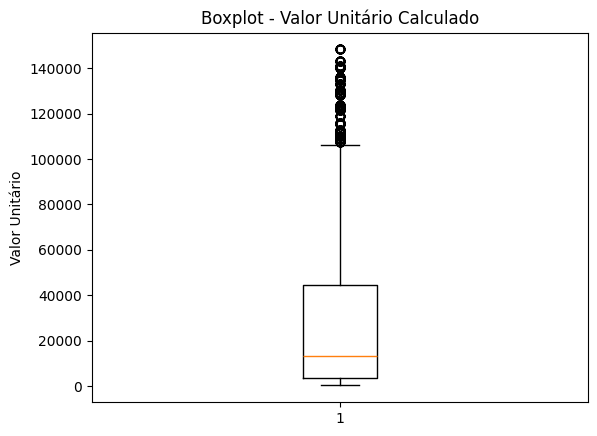

In [158]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_vendas["valor_unitario_calculado"])
plt.title("Boxplot - Valor Unitário Calculado")
plt.ylabel("Valor Unitário")

plt.show()

In [159]:
df_vendas.sort_values(
    by="valor_unitario_calculado",
    ascending=False
)[["id_produto", "valor_unitario_calculado"]].head(20)

,id_produto,valor_unitario_calculado
9602,76,148198.333333
9414,76,148198.333333
6029,76,148198.333333
9422,76,148198.333333
9442,76,148198.333333
5306,76,148198.285714
5058,76,148198.272727
598,76,148198.250000
4103,76,148198.250000
737,76,148198.250000


In [160]:
df_produtos[df_produtos["codigo_produto"] == 76]

,nome_produto,preco,codigo_produto,categoria
79,Motor Diesel Honda Aero 205HP,148198.23,76,propulsao


In [161]:
df_vendas["valor_unitario_calculado"] = df_vendas["valor_unitario_calculado"].round(2)

In [162]:
df_vendas

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,valor_unitario_calculado
0,0,42,105,11,3405.00,2023-09-10,309.55
1,1,3,136,9,16873.90,2024-09-15,1874.88
2,2,25,139,7,9475.30,2024-08-13,1353.61
3,4,20,23,5,55893.00,2023-02-03,11178.60
4,5,8,57,4,451403.90,2024-02-12,112850.98
...,...,...,...,...,...,...,...
9890,9995,30,139,6,8549.00,2023-03-11,1424.83
9891,9996,9,111,7,28497.15,2023-09-17,4071.02
9892,9997,38,123,2,5276.30,2023-06-20,2638.15
9893,9998,33,97,6,771409.50,2024-10-23,128568.25


Top 10 produtos de maior valor:

In [163]:
df_produtos.sort_values(
    by="preco",
    ascending=False
)[["nome_produto", "categoria", "preco"]].head(10)

,nome_produto,categoria,preco
79,Motor Diesel Honda Aero 205HP,propulsao,148198.23
76,Motor de Popa Torqeedo Core Hydra Flux 162HP,propulsao,143159.93
66,Motor Elétrico Torqeedo Ion Orca Vox 186HP,propulsao,139957.67
100,Motor de Popa Tohatsu Evo 168HP,propulsao,135335.07
94,Motor Elétrico Tohatsu Zenith Oceanic 113HP,propulsao,134886.02
86,Motor Diesel Yanmar Dash Nitro 184HP,propulsao,134803.88
74,Motor Elétrico Torqeedo Pulse 300HP,propulsao,130174.06
83,Motor de Popa Volvo Maré 69HP,propulsao,129223.84
84,Motor Elétrico Torqeedo Barracuda Magnum Helix...,propulsao,122148.49
81,Motor Elétrico Honda Mako Axis 131HP,propulsao,121761.56


Os produtos de maior valor agregado são da categoria propulsão.

In [164]:
df_produtos.sort_values(
    by="preco",
    ascending=False
)[["nome_produto", "categoria", "preco"]].tail(10)

,nome_produto,categoria,preco
155,Cabo de Nylon Bruce Core,ancoragem,1163.62
136,Boia de Arqueamento Danforth Core Vortex,ancoragem,963.59
105,Cabo de Nylon Bruce Nexus,ancoragem,832.02
118,Cabo de Nylon Delta Force Magnum Leviathan,ancoragem,830.59
147,Âncora Danforth Vector Evo,ancoragem,826.41
117,Boia de Arqueamento Danforth Tidal Zen Swift,ancoragem,799.29
112,Cabo de Nylon Danforth Evo Aqua Mako,ancoragem,622.70
152,Corrente Delta Vox Ion,ancoragem,495.98
104,Cabo de Nylon Delta Vortex,ancoragem,463.40
108,Cabo de Nylon Danforth Prime,ancoragem,309.54


Os produtos de menor valor agregado são da categoria ancoragem.

In [165]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nome_produto    157 non-null    str    
 1   preco           157 non-null    float64
 2   codigo_produto  157 non-null    int64  
 3   categoria       157 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 5.0 KB


In [166]:
df_produtos["codigo_produto"].duplicated().sum()

np.int64(7)

In [167]:
df_produtos.isna().sum()

nome_produto      0
preco             0
codigo_produto    0
categoria         0
dtype: int64

In [168]:
df_produtos["categoria"].value_counts()

categoria
propulsao      53
ancoragem      53
eletronicos    51
Name: count, dtype: int64

In [169]:
df_produtos[df_produtos["codigo_produto"].duplicated(keep=False)].sort_values("codigo_produto")

,nome_produto,preco,codigo_produto,categoria
36,GPS Lowrance Evo Storm Drift,6067.71,37,eletronicos
37,GPS Lowrance Evo Storm Drift,6067.71,37,eletronicos
62,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
63,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
64,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
65,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
131,Cabo de Nylon Delta Velocity Core Mako,1549.35,127,ancoragem
132,Cabo de Nylon Delta Velocity Core Mako,1549.35,127,ancoragem
124,Boia de Arqueamento Delta Nexus,4349.86,145,ancoragem
150,Boia de Arqueamento Delta Nexus,4349.86,145,ancoragem


In [170]:
df_produtos = df_produtos.drop_duplicates(subset="codigo_produto")

In [171]:
df_produtos["codigo_produto"].duplicated().sum()

np.int64(0)

### Leitura dos arquivos JSON

#### Leitura e carregamento dos dados dos clientes vindos do CRM (clientes_crm.json)

In [88]:
with open(RAW_PATH / "clientes_crm.json", "r", encoding="utf-8") as f:
    clientes_crm_json = json.load(f)

In [89]:
df_clientes = pd.json_normalize(clientes_crm_json)

In [90]:
df_clientes.shape

(49, 4)

In [91]:
df_clientes.head(10)

,full_name,location,code,email
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com
3,Thiago Moreira,"AC , Rio Branco",4,thiago.moreira#gmail.com
4,Pedro Freitas,PA - Santarém Novo,5,pedro.freitas#icloud.com
5,Antônia Coelho Pinheiro Peixoto Cavalcanti,"Fortaleza do Tabocão , TO",6,coelho.pinheiro.peixoto.antônia.cavalcanti@aol...
6,Bianca Barros Rocha Torres Siqueira,PB/Cabedelo,7,torres.barros.rocha.bianca.siqueira#aol.com
7,Luiz Alves Pimentel,SE - Aracaju,8,pimentel.alves.luiz#outlook.com
8,Lucas Guedes Cunha Lopes,PB - João Pessoa,9,lucas.lopes.guedes.cunha#tutanota.com
9,Débora Paiva,Santarém / PA,10,paiva.débora#gmx.com


#### Leitura e carregamento dos dados dos custos de importação (custos_importacao.json)

In [92]:
with open(RAW_PATH / "custos_importacao.json", "r", encoding="utf-8") as f:
    custos_importacao_json = json.load(f)

In [93]:
custos_importacao = pd.json_normalize(custos_importacao_json)

In [94]:
custos_importacao.shape

(150, 4)

In [95]:
custos_importacao.head(10)

,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"[{'start_date': '10/08/2016', 'usd_price': 105..."
1,2,Transponder Furuno Marlin,eletrônicos,"[{'start_date': '23/11/2017', 'usd_price': 432..."
2,3,Radar Furuno Pulse Leviathan,eletrônicos,"[{'start_date': '12/04/2016', 'usd_price': 254..."
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,"[{'start_date': '04/03/2016', 'usd_price': 909..."
4,5,Piloto Automático Furuno Storm,eletrônicos,"[{'start_date': '10/02/2016', 'usd_price': 600..."
5,6,Transponder AIS Vector,eletrônicos,"[{'start_date': '23/07/2020', 'usd_price': 228..."
6,7,Radar AIS Zen,eletrônicos,"[{'start_date': '26/10/2016', 'usd_price': 625..."
7,8,GPS AIS Zen,eletrônicos,"[{'start_date': '06/12/2019', 'usd_price': 119..."
8,9,Transponder AIS Titan Pulse,eletrônicos,"[{'start_date': '26/12/2018', 'usd_price': 101..."
9,10,Piloto Automático Simrad Titan Flux Magnum,eletrônicos,"[{'start_date': '29/05/2018', 'usd_price': 859..."
